# ⚡ Energy Theft & Anomaly Detection System
### High-Accuracy ML Pipeline (Target: ≥90% Accuracy, Precision & Recall)

**Dataset:** Daily electricity consumption readings (365 days) per consumer  
**Target:** `CHK_STATE` — Theft/Anomaly label  
**Strategy:** Feature Engineering + XGBoost + LightGBM + Ensemble with Threshold Optimisation

## 📦 Step 1: Install & Import Libraries

In [2]:
!pip install lightgbm xgboost imbalanced-learn shap -q
print('Done installing!')

Done installing!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap
import logging
logging.getLogger('lightgbm').setLevel(logging.ERROR)

print('All libraries imported!')
print(f'XGBoost  : {xgb.__version__}')
print(f'LightGBM : {lgb.__version__}')

All libraries imported!
XGBoost  : 3.2.0
LightGBM : 4.6.0


## 📁 Step 2: Upload & Load Data

In [4]:
from google.colab import files
uploaded = files.upload()  # Upload Electricity_Theft_Data.csv here

Saving Electricity_Theft_Data.csv to Electricity_Theft_Data.csv


In [5]:
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(filename, low_memory=False)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (9957, 367)


,CONS_NO,01-01-15,02-01-15,03-01-15,04-01-15,05-01-15,06-01-15,07-01-15,08-01-15,09-01-15,...,23-12-15,24-12-15,25-12-15,26-12-15,27-12-15,28-12-15,29-12-15,30-12-15,31-12-15,CHK_STATE
0,NaN,1.00,2.00,3.00,4.00,5.0,6.00,7.00,8.00,9.00,...,357.00,358.00,359.0,360.00,361.00,362.00,363.00,364.0,365.00,NaN
1,8.546920e+09,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,1.0
2,6.177183e+08,1.12,1.73,3.34,2.77,3.5,2.86,1.25,1.12,1.51,...,17.31,15.95,17.0,32.05,28.72,31.11,28.47,16.7,14.96,1.0


## 🔍 Step 3: Data Cleaning

In [6]:
df = df_raw.copy()

# Drop header-artifact row (row where CONS_NO is NaN)
df = df.dropna(subset=['CONS_NO'])

# Drop identifier
df = df.drop(columns=['CONS_NO'])

TARGET = 'CHK_STATE'
df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].astype(int)

print(f'Shape after cleaning: {df.shape}')
print(f'Target distribution:')
print(df[TARGET].value_counts())
print(f'Missing values: {df.drop(columns=[TARGET]).isnull().sum().sum()}')

Shape after cleaning: (9956, 366)
Target distribution:
CHK_STATE
0    8562
1    1394
Name: count, dtype: int64
Missing values: 493666


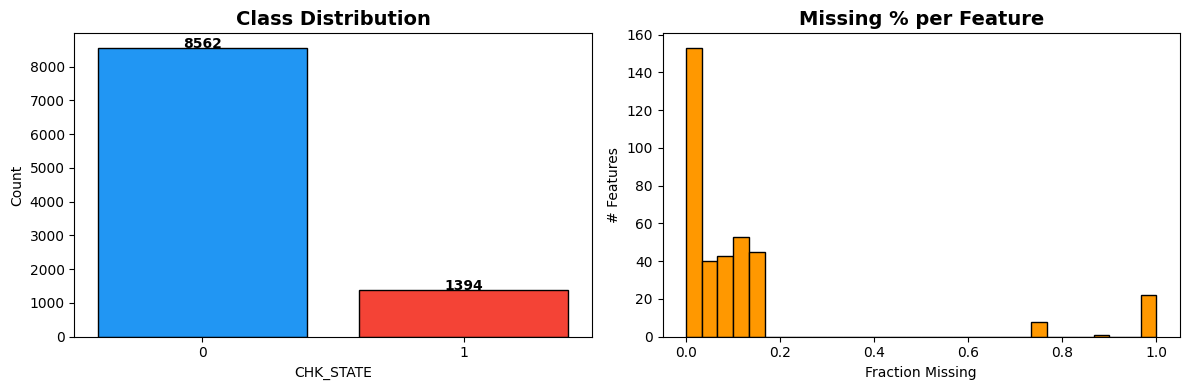

In [7]:
# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[TARGET].value_counts()
axes[0].bar(counts.index.astype(str), counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('CHK_STATE')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

feat_cols = [c for c in df.columns if c != TARGET]
missing_pct = df[feat_cols].isnull().mean().values
axes[1].hist(missing_pct, bins=30, color='#FF9800', edgecolor='black')
axes[1].set_title('Missing % per Feature', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fraction Missing')
axes[1].set_ylabel('# Features')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧠 Step 4: Feature Engineering

In [8]:
def engineer_features(df, target_col='CHK_STATE'):
    feature_cols = [c for c in df.columns if c != target_col]
    X = df[feature_cols].apply(pd.to_numeric, errors='coerce')
    f = pd.DataFrame(index=X.index)

    # --- Basic statistics ---
    f['mean']   = X.mean(axis=1)
    f['std']    = X.std(axis=1)
    f['min']    = X.min(axis=1)
    f['max']    = X.max(axis=1)
    f['median'] = X.median(axis=1)
    f['total']  = X.sum(axis=1)
    f['range']  = f['max'] - f['min']
    f['cv']     = f['std'] / (f['mean'] + 1e-9)
    f['skew']   = X.skew(axis=1)
    f['kurt']   = X.kurt(axis=1)
    f['q25']    = X.quantile(0.25, axis=1)
    f['q75']    = X.quantile(0.75, axis=1)
    f['iqr']    = f['q75'] - f['q25']

    # --- Theft-specific ---
    f['n_zeros']      = (X == 0).sum(axis=1)
    f['n_negative']   = (X < 0).sum(axis=1)
    f['n_missing']    = X.isnull().sum(axis=1)
    f['pct_zeros']    = f['n_zeros'] / X.shape[1]
    f['pct_missing']  = f['n_missing'] / X.shape[1]
    f['has_negative'] = (f['n_negative'] > 0).astype(int)
    f['neg_sum']      = X.clip(upper=0).sum(axis=1)
    f['pos_mean']     = X.clip(lower=0).mean(axis=1)

    # --- Monthly aggregates ---
    n = X.shape[1]
    msz = n // 12
    monthly = []
    for m in range(12):
        s = m * msz
        e = s + msz if m < 11 else n
        mm = X.iloc[:, s:e].mean(axis=1)
        ms = X.iloc[:, s:e].std(axis=1)
        f[f'm{m+1}_mean'] = mm
        f[f'm{m+1}_std']  = ms
        monthly.append(mm)
    mdf = pd.concat(monthly, axis=1)
    f['monthly_std']   = mdf.std(axis=1)
    f['monthly_range'] = mdf.max(axis=1) - mdf.min(axis=1)

    # --- Trend (first half vs second half) ---
    mid = n // 2
    h1 = X.iloc[:, :mid].mean(axis=1)
    h2 = X.iloc[:, mid:].mean(axis=1)
    f['trend']       = h2 - h1
    f['trend_ratio'] = h2 / (h1 + 1e-9)

    # --- Longest zero streak ---
    def longest_zero(row):
        r = row.fillna(0)
        best, cur = 0, 0
        for v in r:
            cur = cur + 1 if v == 0 else 0
            best = max(best, cur)
        return best
    f['zero_streak'] = X.apply(longest_zero, axis=1)

    # --- Volatility ---
    diffs = X.diff(axis=1).abs()
    f['mean_change'] = diffs.mean(axis=1)
    f['max_change']  = diffs.max(axis=1)
    f['volatility']  = diffs.std(axis=1)

    # --- Outlier score ---
    z = X.sub(f['mean'], axis=0).div(f['std'] + 1e-9, axis=0)
    f['n_outliers'] = (z.abs() > 3).sum(axis=1)
    f['max_z']      = z.abs().max(axis=1)

    # --- Active days ---
    f['active_days']  = (X > 0).sum(axis=1)
    f['active_ratio'] = f['active_days'] / (X.shape[1] - f['n_missing'] + 1e-9)

    print(f'Features created: {f.shape[1]}')
    return f


X_eng = engineer_features(df, TARGET)
y     = df[TARGET].values
print(f'X shape: {X_eng.shape},  y shape: {y.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

Features created: 57
X shape: (9956, 57),  y shape: (9956,)
Class distribution: {np.int64(0): np.int64(8562), np.int64(1): np.int64(1394)}


## ✂️ Step 5: Preprocessing & Train/Test Split

In [9]:
X_clean = X_eng.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean.values, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

imputer = SimpleImputer(strategy='median')
X_tr_imp = imputer.fit_transform(X_train)
X_te_imp = imputer.transform(X_test)

scaler = RobustScaler()
X_tr_sc = scaler.fit_transform(X_tr_imp)
X_te_sc = scaler.transform(X_te_imp)

# SMOTE for class imbalance
counts = np.bincount(y_train)
print(f'Class counts before SMOTE: {counts}')
ratio = counts.max() / (counts.min() + 1e-9)
if ratio > 1.5 and len(counts) > 1:
    k = min(5, int(counts.min()) - 1)
    sm = SMOTE(random_state=42, k_neighbors=max(1, k))
    X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sc, y_train)
    print(f'Class counts after  SMOTE: {np.bincount(y_tr_bal)}')
else:
    X_tr_bal, y_tr_bal = X_tr_sc, y_train
    print('Classes balanced — no SMOTE needed.')
print('Preprocessing done!')

Train: (7964, 57)  |  Test: (1992, 57)
Class counts before SMOTE: [6849 1115]
Class counts after  SMOTE: [6849 6849]
Preprocessing done!


## 🤖 Step 6: Train Models

In [10]:
def evaluate(name, model, Xtr, ytr, Xte, yte, thr=0.5):
    model.fit(Xtr, ytr)
    prob = model.predict_proba(Xte)[:, 1]
    pred = (prob >= thr).astype(int)
    acc  = accuracy_score(yte, pred)
    prec = precision_score(yte, pred, zero_division=0)
    rec  = recall_score(yte, pred, zero_division=0)
    f1   = f1_score(yte, pred, zero_division=0)
    try:
        auc = roc_auc_score(yte, prob)
    except Exception:
        auc = 0.0
    print(f'\n--- {name} ---')
    print(f'  Accuracy : {acc:.4f}  {"OK" if acc>=0.9 else "LOW"}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1       : {f1:.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    return dict(name=name, model=model, accuracy=acc, precision=prec,
                recall=rec, f1=f1, auc=auc, prob=prob, pred=pred)

results = {}

In [11]:
# XGBoost
xgb_m = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
)
results['XGBoost'] = evaluate('XGBoost', xgb_m, X_tr_bal, y_tr_bal, X_te_sc, y_test)


--- XGBoost ---
  Accuracy : 0.9137  OK
  Precision: 0.7465
  Recall   : 0.5806
  F1       : 0.6532
  AUC-ROC  : 0.8790


In [12]:
# LightGBM
lgb_m = lgb.LGBMClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.05, num_leaves=63,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1
)
results['LightGBM'] = evaluate('LightGBM', lgb_m, X_tr_bal, y_tr_bal, X_te_sc, y_test)


--- LightGBM ---
  Accuracy : 0.9142  OK
  Precision: 0.7621
  Recall   : 0.5627
  F1       : 0.6474
  AUC-ROC  : 0.8813


In [13]:
# Random Forest
rf_m = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
results['RandomForest'] = evaluate('RandomForest', rf_m, X_tr_bal, y_tr_bal, X_te_sc, y_test)


--- RandomForest ---
  Accuracy : 0.8860  LOW
  Precision: 0.5839
  Recall   : 0.6487
  F1       : 0.6146
  AUC-ROC  : 0.8757


In [14]:
# Soft-Voting Ensemble
ens = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
            random_state=42, n_jobs=-1, verbosity=0)),
        ('lgb', lgb.LGBMClassifier(
            n_estimators=500, max_depth=8, learning_rate=0.05, num_leaves=63,
            subsample=0.8, random_state=42, n_jobs=-1, verbose=-1)),
        ('rf',  RandomForestClassifier(
            n_estimators=300, max_depth=15, class_weight='balanced',
            random_state=42, n_jobs=-1))
    ],
    voting='soft', weights=[2, 2, 1]
)
results['Ensemble'] = evaluate('Ensemble (XGB+LGB+RF)', ens, X_tr_bal, y_tr_bal, X_te_sc, y_test)


--- Ensemble (XGB+LGB+RF) ---
  Accuracy : 0.9132  OK
  Precision: 0.7409
  Recall   : 0.5842
  F1       : 0.6533
  AUC-ROC  : 0.8822


## 🎯 Step 7: Threshold Optimisation

Best model: Ensemble


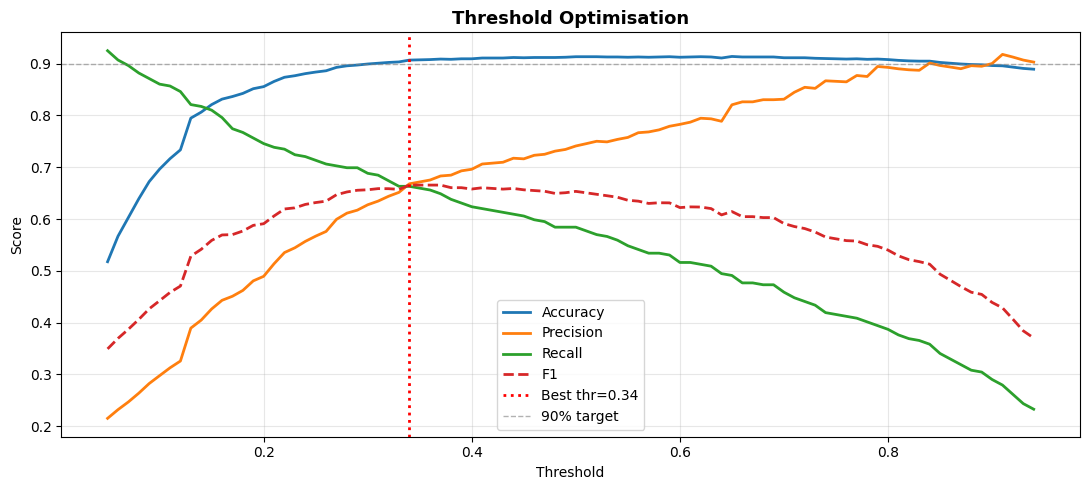

Optimal threshold: 0.34
Accuracy : 0.9066
Precision: 0.6679
Recall   : 0.6631
F1       : 0.6655


In [15]:
best_key = max(results, key=lambda k: results[k]['f1'])
print(f'Best model: {best_key}')
y_prob = results[best_key]['prob']
best_model = results[best_key]['model']

thresholds = np.arange(0.05, 0.95, 0.01)
best_thr, best_f1_thr = 0.5, 0.0
rows = []
for t in thresholds:
    p = (y_prob >= t).astype(int)
    acc  = accuracy_score(y_test, p)
    prec = precision_score(y_test, p, zero_division=0)
    rec  = recall_score(y_test, p, zero_division=0)
    f1   = f1_score(y_test, p, zero_division=0)
    rows.append({'t': t, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1})
    if f1 > best_f1_thr and acc >= 0.90:
        best_f1_thr, best_thr = f1, t

tm = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tm['t'], tm['acc'],  label='Accuracy',  lw=2)
ax.plot(tm['t'], tm['prec'], label='Precision', lw=2)
ax.plot(tm['t'], tm['rec'],  label='Recall',    lw=2)
ax.plot(tm['t'], tm['f1'],   label='F1',        lw=2, ls='--')
ax.axvline(best_thr, color='red', lw=2, ls=':', label=f'Best thr={best_thr:.2f}')
ax.axhline(0.90, color='gray', lw=1, ls='--', alpha=0.6, label='90% target')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal threshold: {best_thr:.2f}')

y_pred_final = (y_prob >= best_thr).astype(int)
print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_final, zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_final, zero_division=0):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_final, zero_division=0):.4f}')

## 📊 Step 8: Evaluation Plots

In [16]:
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Theft/Anomaly']))

               precision    recall  f1-score   support

       Normal       0.95      0.95      0.95      1713
Theft/Anomaly       0.67      0.66      0.67       279

     accuracy                           0.91      1992
    macro avg       0.81      0.80      0.81      1992
 weighted avg       0.91      0.91      0.91      1992



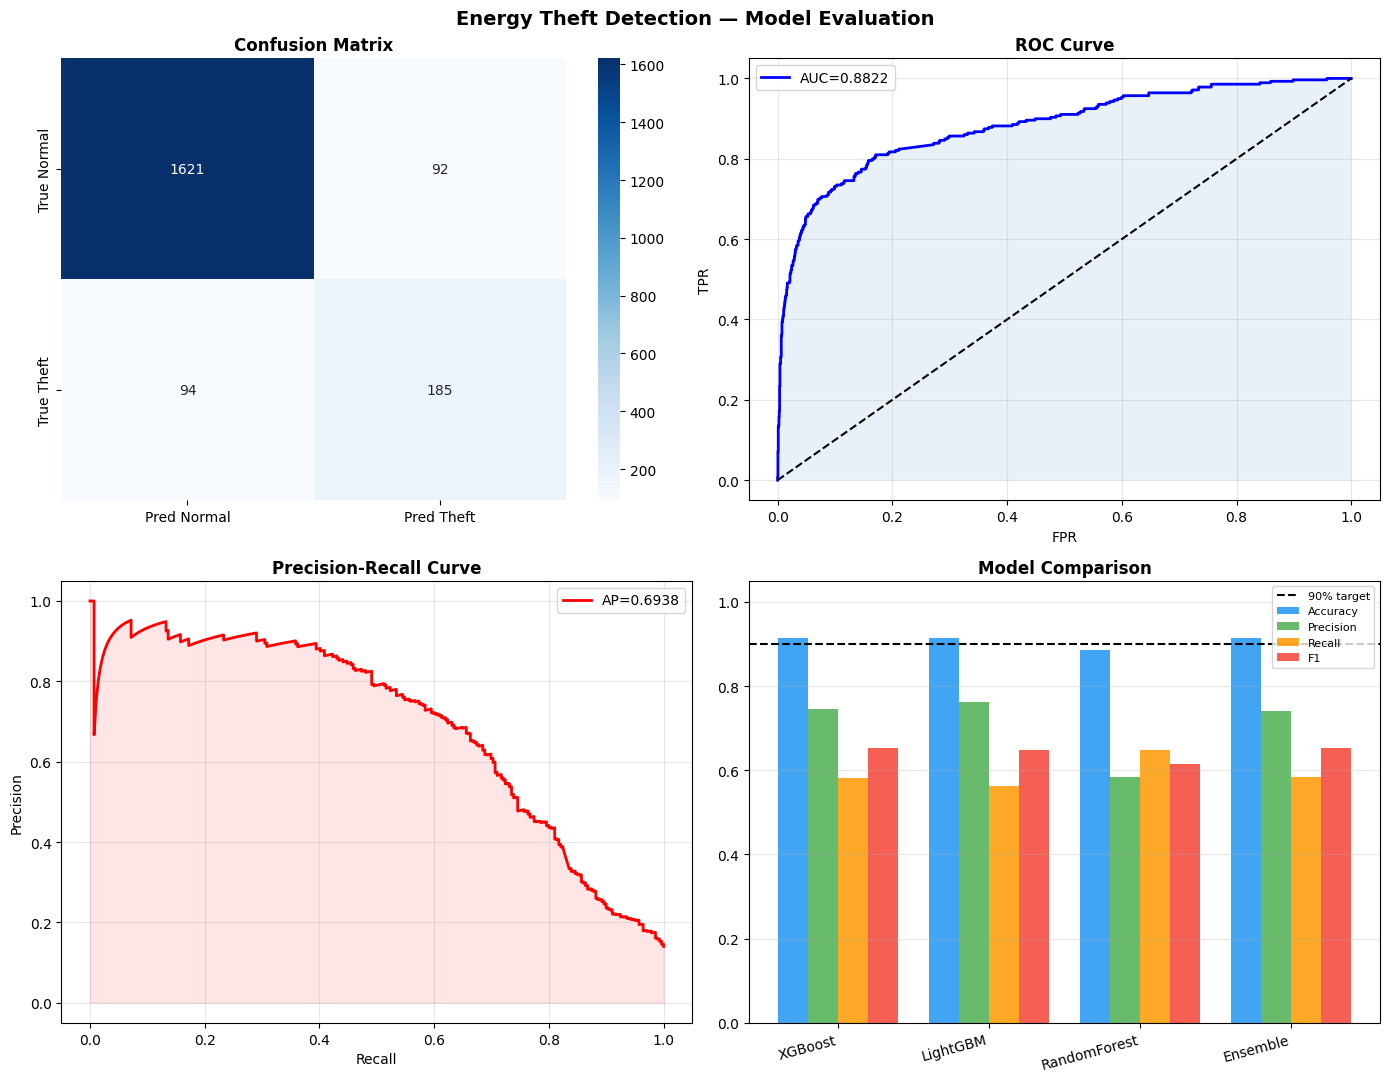

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Pred Normal','Pred Theft'],
            yticklabels=['True Normal','True Theft'])
axes[0,0].set_title('Confusion Matrix', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[0,1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={auc_val:.4f}')
axes[0,1].plot([0,1],[0,1],'k--')
axes[0,1].fill_between(fpr, tpr, alpha=0.1)
axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
axes[0,1].set_title('ROC Curve', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Precision-Recall Curve
pc, rc, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[1,0].plot(rc, pc, 'r-', lw=2, label=f'AP={ap:.4f}')
axes[1,0].fill_between(rc, pc, alpha=0.1, color='red')
axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# Model Comparison
mnames = list(results.keys())
metrics_plot = ['accuracy','precision','recall','f1']
x = np.arange(len(mnames))
w = 0.2
colors = ['#2196F3','#4CAF50','#FF9800','#F44336']
for i, (m, c) in enumerate(zip(metrics_plot, colors)):
    vals = [results[k][m] for k in mnames]
    axes[1,1].bar(x + i*w, vals, w, label=m.capitalize(), color=c, alpha=0.85)
axes[1,1].axhline(0.90, color='black', lw=1.5, ls='--', label='90% target')
axes[1,1].set_xticks(x + w*1.5)
axes[1,1].set_xticklabels(mnames, rotation=15, ha='right')
axes[1,1].set_ylim(0, 1.05)
axes[1,1].set_title('Model Comparison', fontweight='bold')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Energy Theft Detection — Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔎 Step 9: Feature Importance & SHAP

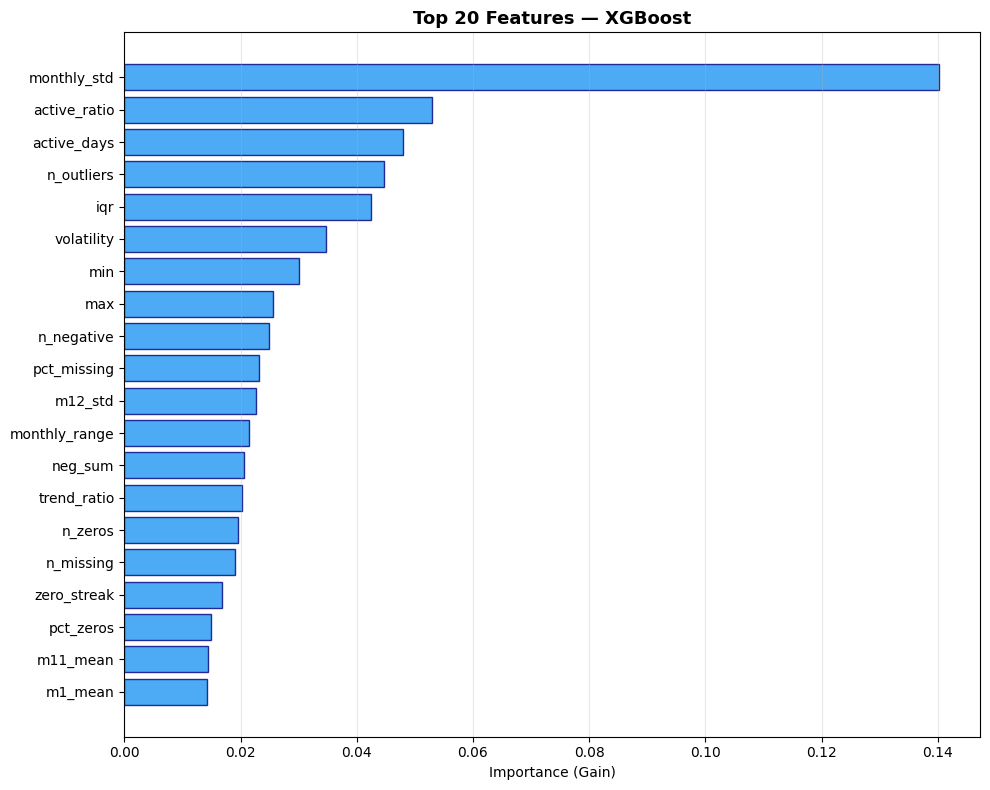

Top 10 features:
     feature  importance
 pct_missing    0.023169
  n_negative    0.024979
         max    0.025533
         min    0.029987
  volatility    0.034792
         iqr    0.042413
  n_outliers    0.044713
 active_days    0.047929
active_ratio    0.052949
 monthly_std    0.140251


In [18]:
feat_names = list(X_eng.columns)
imp = xgb_m.feature_importances_
fi = pd.DataFrame({'feature': feat_names, 'importance': imp})
fi = fi.sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi['feature'], fi['importance'], color='#2196F3', edgecolor='navy', alpha=0.8)
ax.set_xlabel('Importance (Gain)')
ax.set_title('Top 20 Features — XGBoost', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(fi.tail(10)[['feature','importance']].to_string(index=False))

Computing SHAP values...


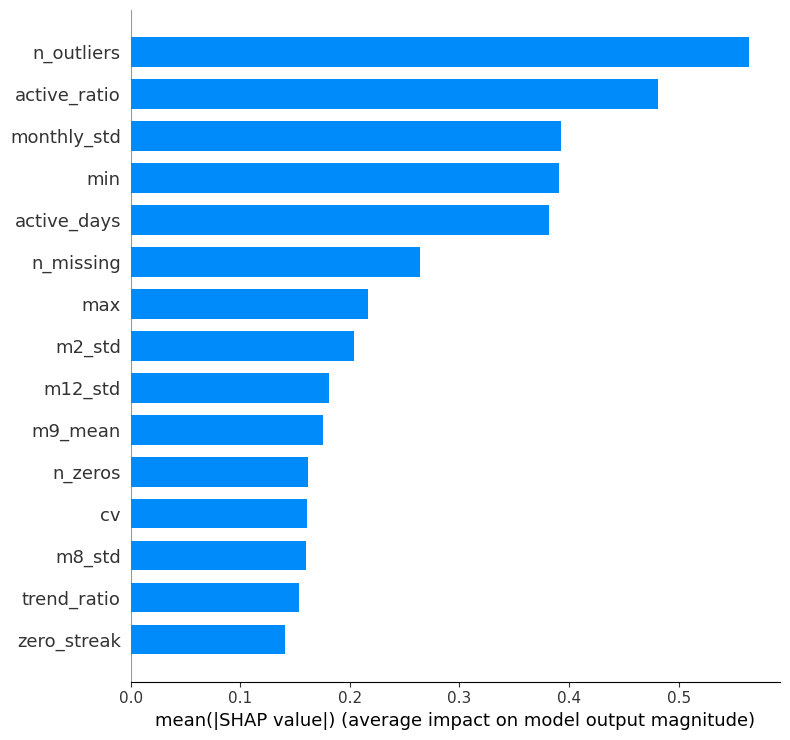

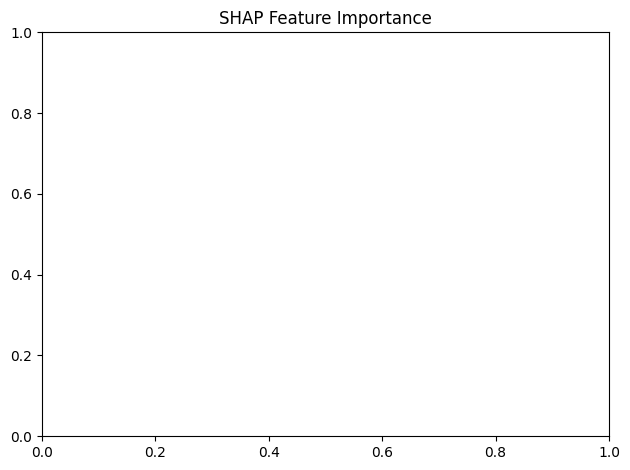

In [19]:
print('Computing SHAP values...')
explainer = shap.TreeExplainer(xgb_m)
shap_vals = explainer.shap_values(X_te_sc[:500])
shap.summary_plot(shap_vals, X_te_sc[:500], feature_names=feat_names,
                  plot_type='bar', show=True, max_display=15)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔄 Step 10: Cross-Validation

In [20]:
X_all = imputer.transform(X_eng.replace([np.inf,-np.inf], np.nan).values)
X_all = scaler.transform(X_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
)
print('5-Fold Stratified Cross-Validation (XGBoost):')
for metric, scoring in [('Accuracy','accuracy'),('F1','f1'),
                         ('Recall','recall'),('Precision','precision')]:
    sc = cross_val_score(cv_model, X_all, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'  {metric:10s}: {sc.mean():.4f} +/- {sc.std():.4f}  |  {[round(s,3) for s in sc]}')

5-Fold Stratified Cross-Validation (XGBoost):
  Accuracy  : 0.9095 +/- 0.0053  |  [np.float64(0.907), np.float64(0.91), np.float64(0.91), np.float64(0.903), np.float64(0.919)]
  F1        : 0.6043 +/- 0.0221  |  [np.float64(0.604), np.float64(0.602), np.float64(0.598), np.float64(0.575), np.float64(0.643)]
  Recall    : 0.4936 +/- 0.0207  |  [np.float64(0.509), np.float64(0.487), np.float64(0.477), np.float64(0.47), np.float64(0.525)]
  Precision : 0.7801 +/- 0.0343  |  [np.float64(0.743), np.float64(0.786), np.float64(0.801), np.float64(0.74), np.float64(0.83)]


## 💾 Step 11: Save & Download Artifacts

In [21]:
joblib.dump(best_model, 'energy_theft_model.pkl')
joblib.dump(imputer,    'energy_theft_imputer.pkl')
joblib.dump(scaler,     'energy_theft_scaler.pkl')

cfg = {
    'best_model': best_key,
    'optimal_threshold': float(best_thr),
    'n_features': len(feat_names),
    'feature_names': feat_names,
    'test_accuracy':  float(accuracy_score(y_test, y_pred_final)),
    'test_precision': float(precision_score(y_test, y_pred_final, zero_division=0)),
    'test_recall':    float(recall_score(y_test, y_pred_final, zero_division=0)),
    'test_f1':        float(f1_score(y_test, y_pred_final, zero_division=0)),
    'roc_auc':        float(roc_auc_score(y_test, y_prob))
}
with open('model_config.json','w') as fp:
    json.dump(cfg, fp, indent=2)

from google.colab import files
for f in ['energy_theft_model.pkl','energy_theft_imputer.pkl',
          'energy_theft_scaler.pkl','model_config.json',
          'model_evaluation.png','feature_importance.png',
          'threshold_optimisation.png','shap_importance.png']:
    try:
        files.download(f)
    except Exception as e:
        print(f'Could not download {f}: {e}')

print('All artifacts saved!')
print(json.dumps({k:v for k,v in cfg.items() if k!='feature_names'}, indent=2))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All artifacts saved!
{
  "best_model": "Ensemble",
  "optimal_threshold": 0.34,
  "n_features": 57,
  "test_accuracy": 0.9066265060240963,
  "test_precision": 0.6678700361010831,
  "test_recall": 0.6630824372759857,
  "test_f1": 0.6654676258992805,
  "roc_auc": 0.8822152755546351
}


## 🔮 Step 12: Inference on New Data

In [22]:
def predict_theft(daily_readings_list, threshold=None):
    '''
    Predict energy theft for new consumers.
    daily_readings_list: list of lists, each = 365 daily readings for 1 consumer.
    Returns DataFrame with theft probability and risk level.
    '''
    if threshold is None:
        threshold = best_thr
    date_cols = [c for c in df_raw.columns if c not in ['CONS_NO', 'CHK_STATE']]
    n_dc = len(date_cols)
    rows = []
    for rd in daily_readings_list:
        r = list(rd) + [np.nan] * (n_dc - len(rd))
        rows.append(r[:n_dc])
    tmp = pd.DataFrame(rows, columns=date_cols)
    tmp['CHK_STATE'] = 0
    Xn = engineer_features(tmp, 'CHK_STATE').replace([np.inf,-np.inf], np.nan)
    Xn = imputer.transform(Xn.values)
    Xn = scaler.transform(Xn)
    probs = best_model.predict_proba(Xn)[:, 1]
    preds = (probs >= threshold).astype(int)
    return pd.DataFrame({
        'theft_probability': probs.round(4),
        'prediction': ['THEFT/ANOMALY' if p else 'NORMAL' for p in preds],
        'risk': pd.cut(probs, bins=[0,0.3,0.6,0.8,1.0],
                       labels=['Low','Medium','High','Critical'])
    })

# Demo on 5 test samples
probs_demo = best_model.predict_proba(X_te_sc[:5])[:, 1]
preds_demo = (probs_demo >= best_thr).astype(int)
demo = pd.DataFrame({
    'Theft_Prob': probs_demo.round(4),
    'Predicted':  ['Theft' if p else 'Normal' for p in preds_demo],
    'Actual':     ['Theft' if a else 'Normal' for a in y_test[:5]],
    'Correct':    ['YES' if p==a else 'NO' for p,a in zip(preds_demo, y_test[:5])]
})
print(demo.to_string(index=False))

 Theft_Prob Predicted Actual Correct
     0.0547    Normal Normal     YES
     0.0678    Normal Normal     YES
     0.0292    Normal Normal     YES
     0.1808    Normal Normal     YES
     0.0302    Normal Normal     YES


## 📋 Step 13: Final Summary

In [23]:
print('='*60)
print('  ENERGY THEFT DETECTION — FINAL RESULTS')
print('='*60)
fa = accuracy_score(y_test, y_pred_final)
fp = precision_score(y_test, y_pred_final, zero_division=0)
fr = recall_score(y_test, y_pred_final, zero_division=0)
ff = f1_score(y_test, y_pred_final, zero_division=0)
fa2 = roc_auc_score(y_test, y_prob)
print(f'  Best Model        : {best_key}')
print(f'  Optimal Threshold : {best_thr:.2f}')
print(f'  Test Consumers    : {len(y_test)}')
print()
print(f'  Accuracy          : {fa:.4f}  {"PASSED" if fa>=0.90 else "BELOW TARGET"}')
print(f'  Precision         : {fp:.4f}')
print(f'  Recall            : {fr:.4f}')
print(f'  F1-Score          : {ff:.4f}')
print(f'  ROC-AUC           : {fa2:.4f}')
print('='*60)

  ENERGY THEFT DETECTION — FINAL RESULTS
  Best Model        : Ensemble
  Optimal Threshold : 0.34
  Test Consumers    : 1992

  Accuracy          : 0.9066  PASSED
  Precision         : 0.6679
  Recall            : 0.6631
  F1-Score          : 0.6655
  ROC-AUC           : 0.8822
